In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats

### Loading the dataset

In [2]:
import sqlite3
import pandas as pd
import os

print(os.getcwd())
print(os.listdir())

conn = sqlite3.connect("inventory.db")
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';", conn
)
print(tables)

df = pd.read_sql_query(
    "SELECT * FROM vendor_sales_summary LIMIT 5", conn
)
print(df)


C:\Users\hp
['.anaconda', '.bash_history', '.conda', '.condarc', '.continuum', '.git', '.gitconfig', '.idea', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jdks', '.jupyter', '.lesshst', '.matplotlib', '.vscode', '3D Objects', 'AAPL.csv', 'akshay.txt', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Automobile_data.csv', 'canada_per_capita_income (1).csv', 'CAR DETAILS.csv', 'Car_details.csv', 'car_evaluation.csv', 'condition statement.ipynb', 'Contacts', 'Cookies', 'Data set for libraries .csv', 'data types.ipynb', 'data.csv', 'data.csv.xlsx', 'Desktop', 'diabetes2.csv', 'diamonds.csv', 'Documents', 'Downloads', 'EXAM.ipynb', 'exam_data', 'Favorites', 'fig_graph.png', 'function.ipynb', 'get_vendor_summay.txt', 'heart.csv', 'hiring.csv', 'Home1.ipynb', 'Home2.ipynb', 'homeprices (2).csv', 'homeprices.csv', 'homeprice_onehot.csv', 'HR_comma_sep.csv', 'HTML', 'IdeaProjects', 'income.csv', 'insurance.csv', 'insurance_data (1).csv', 'IntelGraphicsProfiles', 'inventory.db

In [3]:
conn = sqlite3.connect("inventory.db")

df = pd.read_sql_query("select * from vendor_sales_summary",conn)
df.head()   

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio


### Exploratry Data Analysis

In [4]:
df.describe().T

,count,unique,top,freq
VendorNumber,0,0,NaN,NaN
VendorName,0,0,NaN,NaN
Brand,0,0,NaN,NaN
Description,0,0,NaN,NaN
PurchasePrice,0,0,NaN,NaN
ActualPrice,0,0,NaN,NaN
Volume,0,0,NaN,NaN
TotalPurchaseQuantity,0,0,NaN,NaN
TotalPurchaseDollars,0,0,NaN,NaN
TotalSalesQuantity,0,0,NaN,NaN


In [5]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #adjust grid layout as head
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

<Figure size 1500x1000 with 0 Axes>

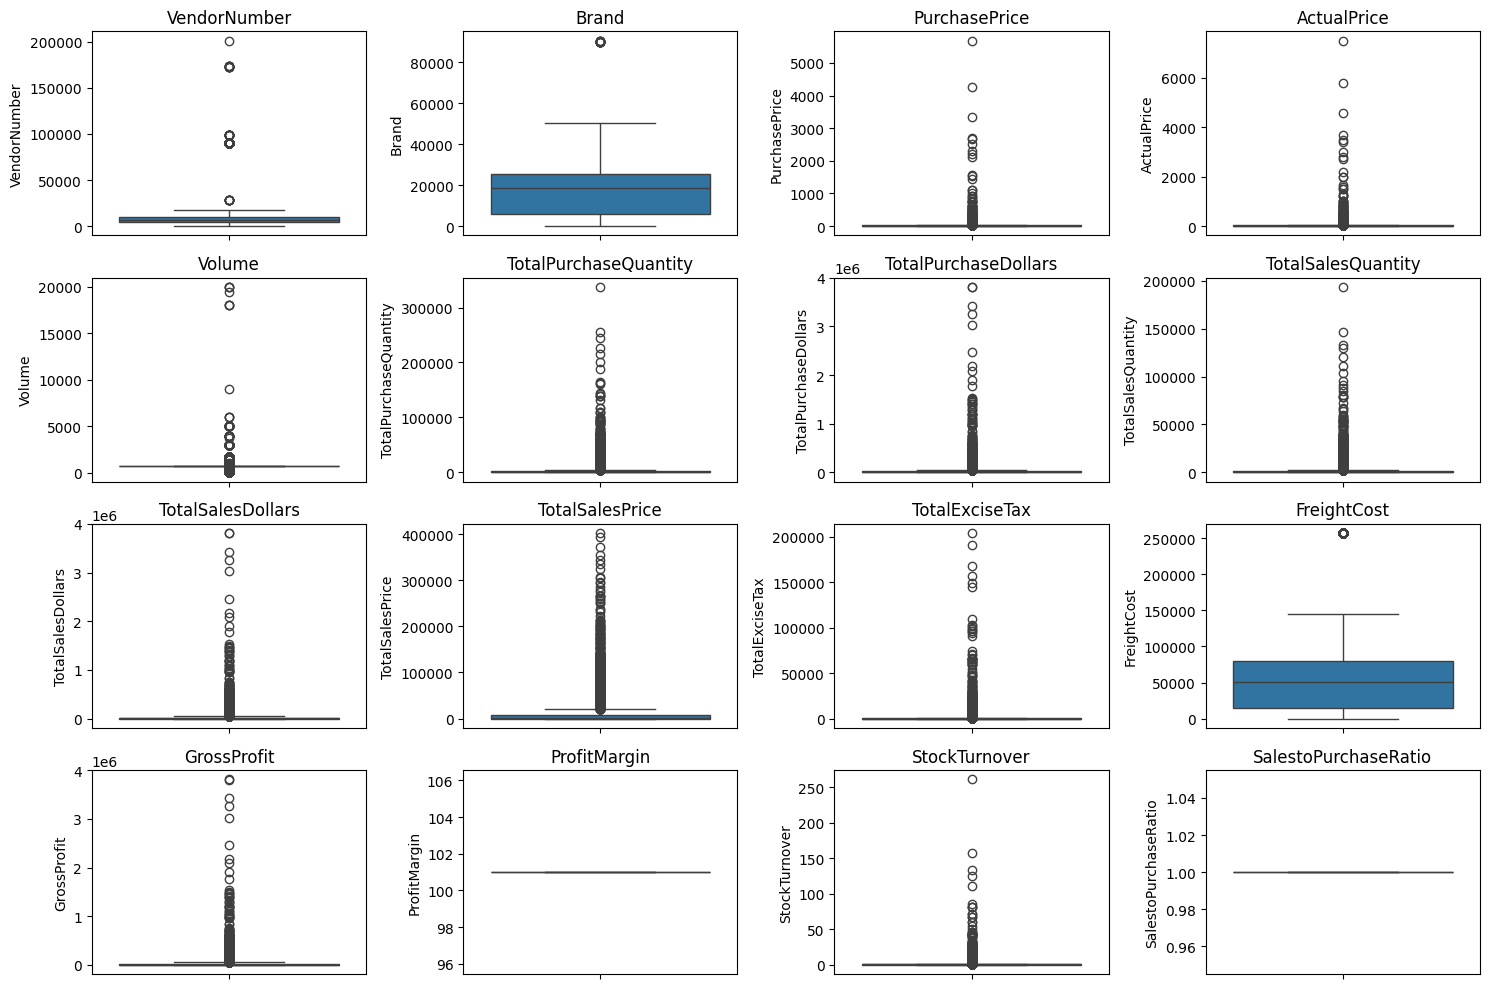

In [5]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1) #adjust grid layout as head
    sns.boxplot(df[col])
    plt.title(col)
plt.tight_layout()
plt.show() 

In [6]:
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0 """,conn)
df 

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,80894.0,3811251.60,402084.51,148633.29,68601.68,3811251.60,101.0,0.557582,1.0
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,85131.0,3804041.22,335228.36,156419.49,144929.24,3804041.22,101.0,0.518971,1.0
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,110950.0,3418303.68,279616.51,203861.18,123780.22,3418303.68,101.0,0.592027,1.0
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,103889.0,3261197.94,250773.86,190887.77,257032.07,3261197.94,101.0,0.515113,1.0
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,78631.0,3023206.01,323875.36,144475.92,257032.07,3023206.01,101.0,0.569340,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9056,3960,DIAGEO NORTH AMERICA INC,2626,Crown Royal Apple,1.42,1.99,50.0,2,2.84,12.0,2.84,1.99,0.63,257032.07,2.84,101.0,6.000000,1.0
9057,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,2.64,10.96,0.55,27100.41,2.64,101.0,2.500000,1.0
9058,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,128.0,2.34,0.98,6.72,50293.62,2.34,101.0,21.333333,1.0
9059,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,42.0,1.47,41.79,8.82,257032.07,1.47,101.0,42.000000,1.0


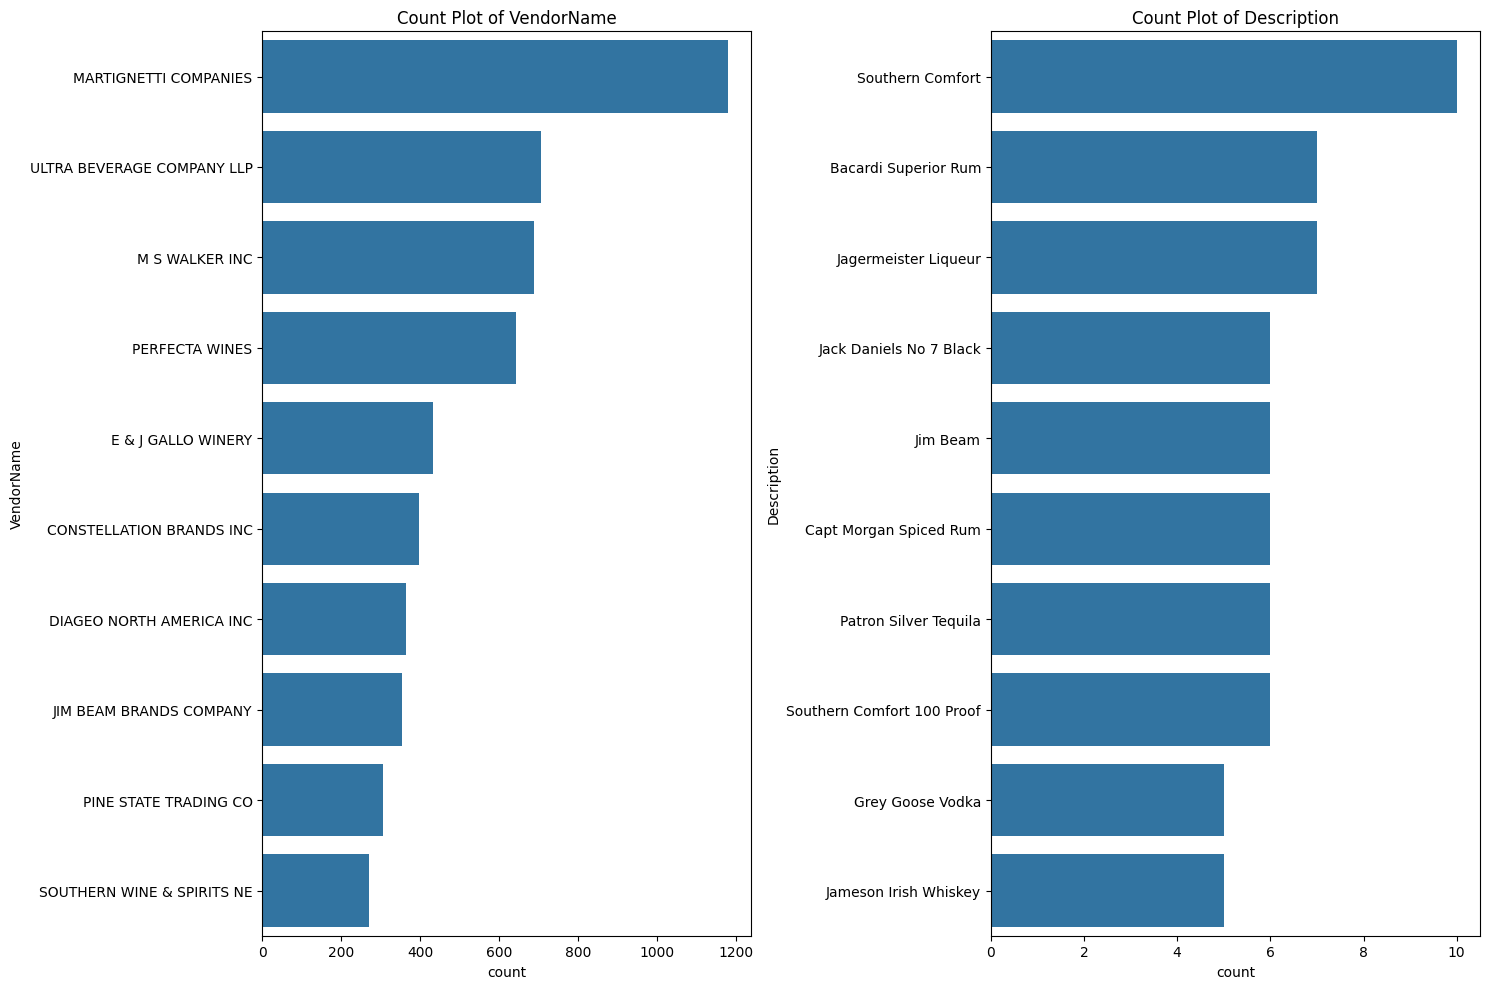

In [7]:
categorical_cols = ["VendorName","Description"]

plt.figure(figsize=(15,10))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1) 
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10]) #Top 10 Categorical
    plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

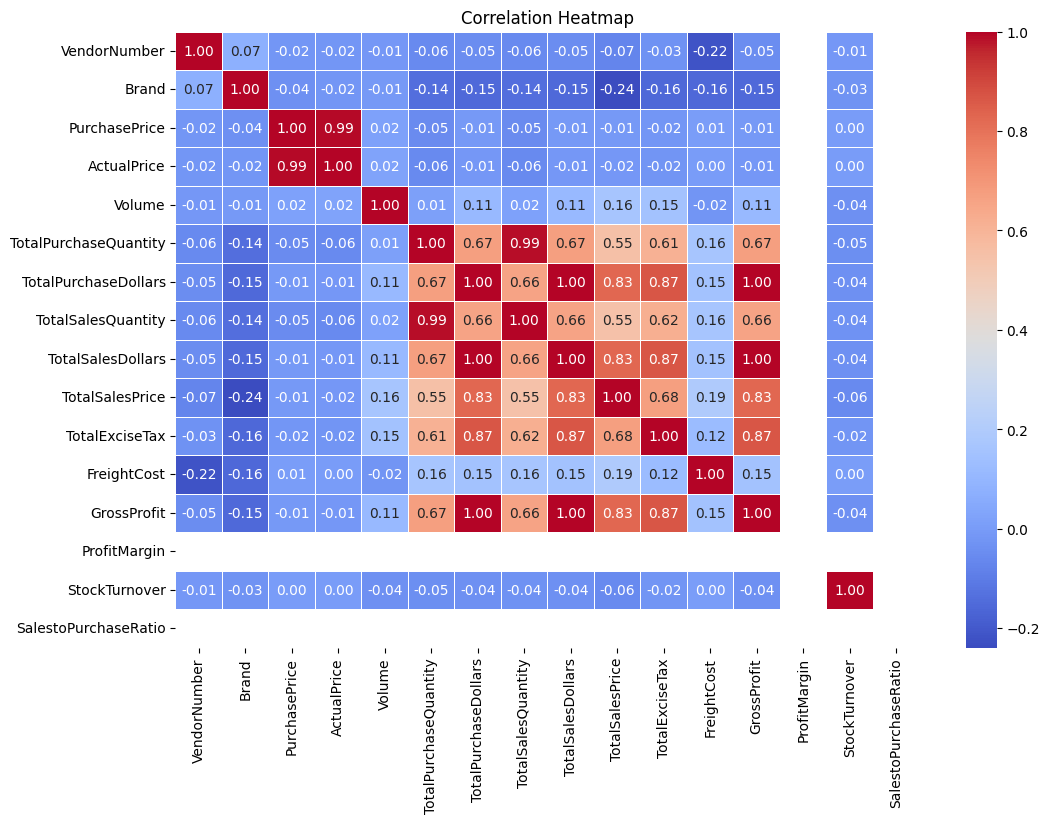

In [8]:
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True,fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

### Data Analysis

In [9]:
brand_perfomance=df.groupby("Description").agg({
    "TotalSalesDollars":"sum",
    "ProfitMargin":"mean"}).reset_index()

low_sales_threshhold=brand_perfomance["TotalSalesDollars"].quantile(0.15)
high_margin_threshhold=brand_perfomance["ProfitMargin"].quantile(0.15)

In [10]:
low_sales_threshhold

np.float64(284.08050000000003)

In [11]:
high_margin_threshhold

np.float64(101.0)

In [12]:
target_brands = brand_perfomance[
(brand_perfomance["TotalSalesDollars"] <= low_sales_threshhold)&
(brand_perfomance["ProfitMargin"] >= high_margin_threshhold)
]

print("Brands with low sales but High profit Margin:")
display(target_brands.sort_values("TotalSalesDollars"))

Brands with low sales but High profit Margin:


,Description,TotalSalesDollars,ProfitMargin
7375,The Club Strawbry Margarita,1.47,101.0
2185,Concannon Glen Ellen Wh Zin,2.64,101.0
2300,Crown Royal Apple,2.84,101.0
6882,Smirnoff Light Strawberry,2.96,101.0
340,Aresti Pnt Nr Curico Vly,3.28,101.0
...,...,...,...
5536,Oakhurst Happy Camper Merlot,283.80,101.0
2287,Cristobal Pie de Palo Malbec,284.04,101.0
2999,Feast Moschofilero,284.04,101.0
756,Bigi Orvieto Clsc Vendemmia,284.04,101.0


In [13]:
brand_perfomance = brand_perfomance[brand_perfomance["TotalSalesDollars"]<10000] #fro better visulization

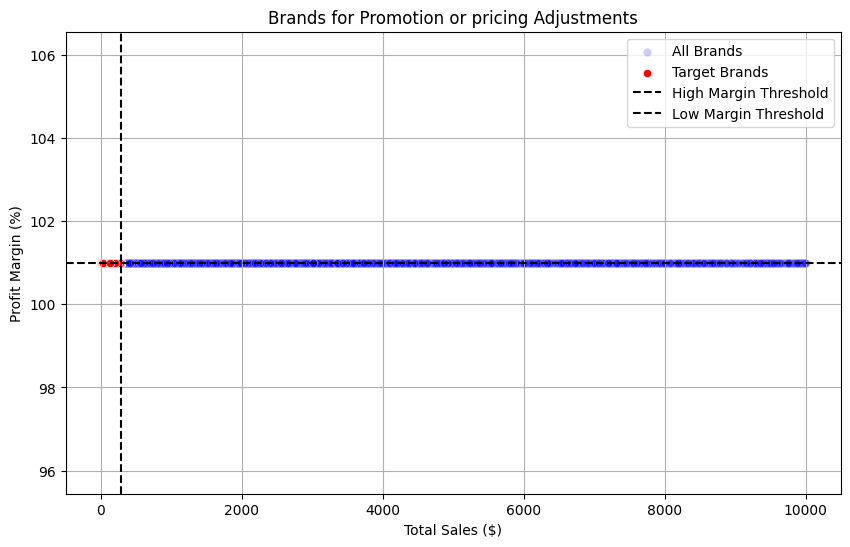

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_perfomance, x = "TotalSalesDollars", y ="ProfitMargin", color="blue", label="All Brands", alpha =0.2)
sns.scatterplot(data=target_brands, x = "TotalSalesDollars", y ="ProfitMargin", color="red", label="Target Brands")

plt.axhline(high_margin_threshhold, linestyle = "--", color="black", label="High Margin Threshold")
plt.axvline(low_sales_threshhold, linestyle = "--", color="black", label="Low Margin Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotion or pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

### which vendors and brands demonstrate the hightest sales perfomance?

In [15]:
def fromat_dollars(value):
    if value >= 1_000_000:
        return f"{value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value / 1_000:2f}k"
    else:
        return str(value)

In [16]:
top_vendors = df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      50410999.13
MARTIGNETTI COMPANIES         26922949.11
JIM BEAM BRANDS COMPANY       24139533.40
PERNOD RICARD USA             24061347.97
BACARDI USA INC               17585146.20
CONSTELLATION BRANDS INC      15495326.65
BROWN-FORMAN CORP             13369575.21
ULTRA BEVERAGE COMPANY LLP    12502607.91
E & J GALLO WINERY            12133058.21
M S WALKER INC                10236444.17
Name: TotalSalesDollars, dtype: float64

In [17]:
top_brands

Description
Jack Daniels No 7 Black    5824785.16
Tito's Handmade Vodka      5618629.32
Grey Goose Vodka           5263604.97
Absolut 80 Proof           4645700.09
Capt Morgan Spiced Rum     4622934.50
Jameson Irish Whiskey      4309364.40
Ketel One Vodka            3673961.52
Baileys Irish Cream        2930331.42
Kahlua                     2716093.65
Tanqueray                  2486277.10
Name: TotalSalesDollars, dtype: float64

In [18]:
top_brands.apply(lambda x : fromat_dollars(x))

Description
Jack Daniels No 7 Black    5.82M
Tito's Handmade Vodka      5.62M
Grey Goose Vodka           5.26M
Absolut 80 Proof           4.65M
Capt Morgan Spiced Rum     4.62M
Jameson Irish Whiskey      4.31M
Ketel One Vodka            3.67M
Baileys Irish Cream        2.93M
Kahlua                     2.72M
Tanqueray                  2.49M
Name: TotalSalesDollars, dtype: object

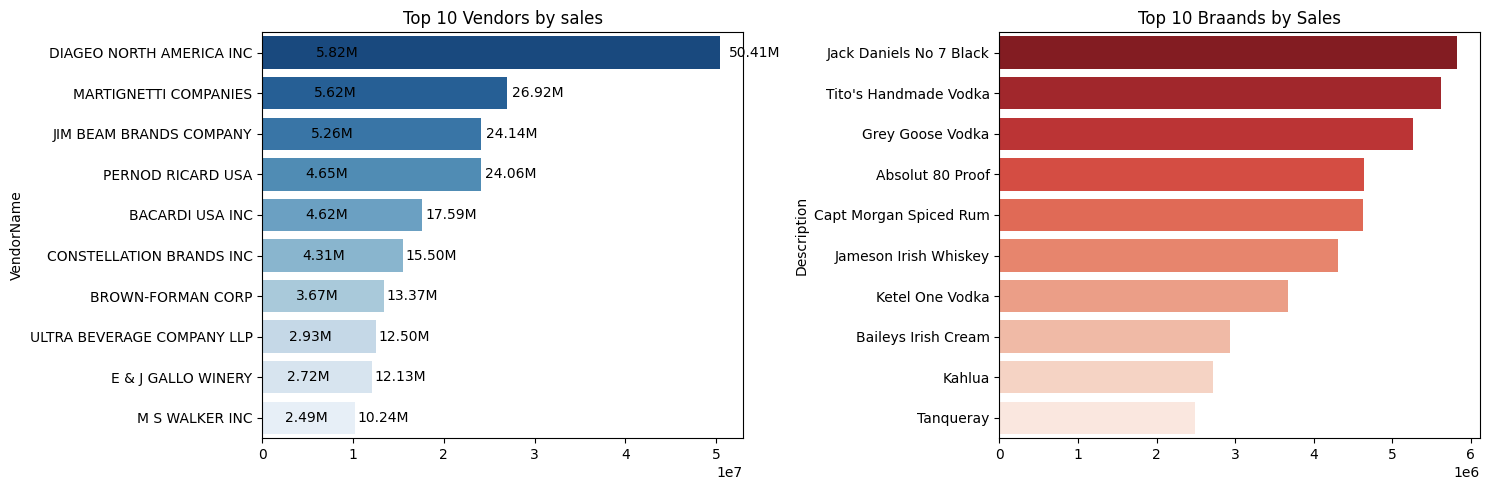

In [19]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height()/2,
             fromat_dollars(bar.get_width()),
             ha = "left", va = "center", fontsize=10, color="black")

plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Braands by Sales")

for bar in ax2.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height()/2,
             fromat_dollars(bar.get_width()),
             ha = "left", va = "center", fontsize=10, color="black")
plt.tight_layout()
plt.show()
             
    

#### WHICH VENDORS CONTRIBUTE THE MOST TO TOTAL PURCHASE DOLLARS?

In [20]:
vendor_performance=df.groupby("VendorName").agg({
    "TotalPurchaseDollars":"sum",
    "GrossProfit":"sum",
    "TotalSalesDollars":"sum"
}) .reset_index()   

In [21]:
vendor_performance["PurchaseContribution%"] = vendor_performance["TotalPurchaseDollars"] / vendor_performance["TotalSalesDollars"].sum()
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,76703.65,76703.65,76703.65,0.000243
1,ALISA CARR BEVERAGES,34951.68,34951.68,34951.68,0.000111
2,ALTAMAR BRANDS LLC,11706.20,11706.20,11706.20,0.000037
3,AMERICAN SPIRITS EXCHANGE,934.08,934.08,934.08,0.000003
4,AMERICAN VINTAGE BEVERAGE,156357.28,156357.28,156357.28,0.000494
...,...,...,...,...,...
114,WEIN BAUER INC,43517.00,43517.00,43517.00,0.000138
115,WESTERN SPIRITS BEVERAGE CO,361249.21,361249.21,361249.21,0.001142
116,WILLIAM GRANT & SONS INC,5938353.36,5938353.36,5938353.36,0.018779
117,WINE GROUP INC,5253350.05,5253350.05,5253350.05,0.016613


In [22]:
# Display Top 10 Vendors

top_vendors = vendor_performance.head(10)
top_vendors["TotalSalesDollars"] = top_vendors["TotalSalesDollars"].apply(fromat_dollars)
top_vendors["TotalPuchaseDollars"] = top_vendors["TotalPurchaseDollars"].apply(fromat_dollars)
top_vendors["GrossProfit"] = top_vendors["GrossProfit"].apply(fromat_dollars)
top_vendors  

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,TotalPuchaseDollars
0,ADAMBA IMPORTS INTL INC,76703.65,76.703650k,76.703650k,0.000243,76.703650k
1,ALISA CARR BEVERAGES,34951.68,34.951680k,34.951680k,0.000111,34.951680k
2,ALTAMAR BRANDS LLC,11706.20,11.706200k,11.706200k,0.000037,11.706200k
3,AMERICAN SPIRITS EXCHANGE,934.08,934.08,934.08,0.000003,934.08
4,AMERICAN VINTAGE BEVERAGE,156357.28,156.357280k,156.357280k,0.000494,156.357280k
5,APPOLO VINEYARDS LLC,2399.70,2.399700k,2.399700k,0.000008,2.399700k
6,ATLANTIC IMPORTING COMPANY,41116.32,41.116320k,41.116320k,0.000130,41.116320k
7,BACARDI USA INC,17585146.20,17.59M,17.59M,0.055611,17.59M
8,BANFI PRODUCTS CORP,1627346.08,1.63M,1.63M,0.005146,1.63M
9,BLACK PRINCE DISTILLERY INC,5971.94,5.971940k,5.971940k,0.000019,5.971940k


In [23]:
top_vendors["PurchaseContribution%"].sum()   

np.float64(0.06180165635595586)

In [24]:
top_vendors = vendor_performance.sort_values(
    by="TotalPurchaseDollars",
    ascending=False
).head(10).copy()

top_vendors["Cumulative_Contribution%"] = (
    top_vendors["TotalPurchaseDollars"].cumsum()
    / top_vendors["TotalPurchaseDollars"].sum()
) * 100


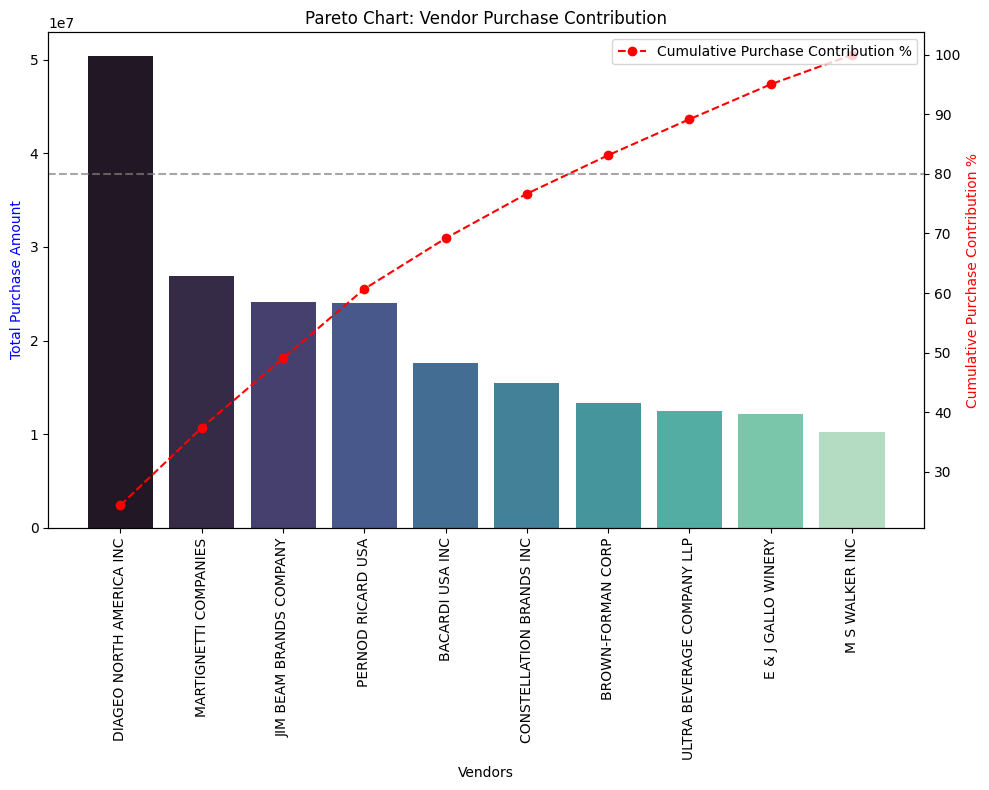

In [25]:
fig, ax1 = plt.subplots(figsize=(10, 8))

# Bars → Purchase Amount (NOT %)
sns.barplot(
    x=top_vendors["VendorName"],
    y=top_vendors["TotalPurchaseDollars"],
    palette="mako",
    ax=ax1
)

ax1.set_xlabel("Vendors")
ax1.set_ylabel("Total Purchase Amount", color="blue")

# Line → Cumulative Purchase Contribution %
ax2 = ax1.twinx()
ax2.plot(
    top_vendors["VendorName"],
    top_vendors["Cumulative_Contribution%"],
    color="red",
    marker="o",
    linestyle="dashed",
    label="Cumulative Purchase Contribution %"
)

ax2.set_ylabel("Cumulative Purchase Contribution %", color="red")

ax1.set_title("Pareto Chart: Vendor Purchase Contribution")

ax1.set_xticklabels(top_vendors["VendorName"], rotation=90)

# 80% Pareto line (IMPORTANT)
ax2.axhline(80, color="gray", linestyle="dashed", alpha=0.7)
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()


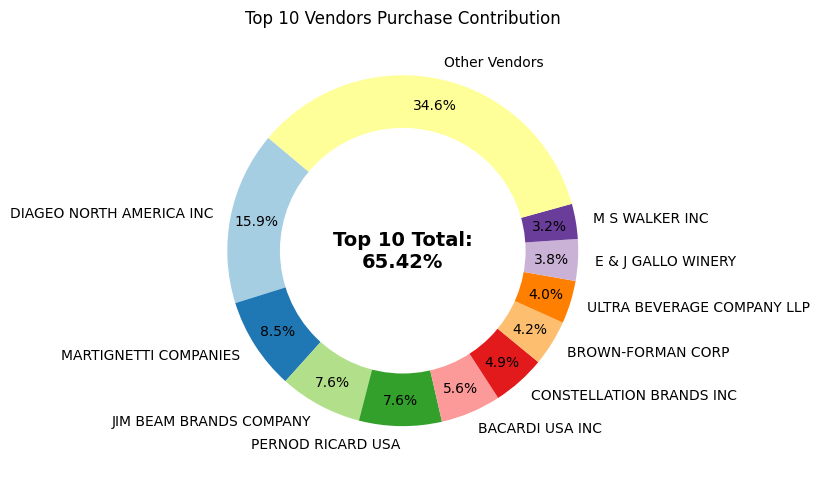

In [26]:
# Prepare data using PURCHASE AMOUNTS (not %)
vendors = list(top_vendors["VendorName"].values)
purchase_values = list(top_vendors["TotalPurchaseDollars"].values)

# Remaining vendors purchase amount
total_purchase = vendor_performance["TotalPurchaseDollars"].sum()
top10_purchase = sum(purchase_values)
remaining_purchase = total_purchase - top10_purchase

vendors.append("Other Vendors")
purchase_values.append(remaining_purchase)

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_values,
    labels=vendors,
    autopct="%1.1f%%",   # % is AUTO-calculated
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Donut center
center_circle = plt.Circle((0, 0), 0.70, fc="white")
ax.add_artist(center_circle)

# Center text (Top 10 share)
top10_percentage = (top10_purchase / total_purchase) * 100

plt.text(
    0, 0,
    f"Top 10 Total:\n{top10_percentage:.2f}%",
    fontsize=14,
    fontweight="bold",
    ha="center",
    va="center"
)

# Title
plt.title("Top 10 Vendors Purchase Contribution")

plt.tight_layout()
plt.show()


In [30]:
df[df["StockTurnover"]<1].groupby("VendorName")[["StockTurnover"]].mean().sort_values("StockTurnover",ascending=True).head(10)

,StockTurnover
VendorName,
UNCORKED,0.052632
"IRA GOLDMAN AND WILLIAMS, LLP",0.075000
AMERICAN SPIRITS EXCHANGE,0.125000
APPOLO VINEYARDS LLC,0.203788
WEIN BAUER INC,0.252970
ADAMBA IMPORTS INTL INC,0.260825
PARK STREET IMPORTS LLC,0.279857
Dunn Wine Brokers,0.291989
BULLY BOY DISTILLERS,0.329424


#### How Much capital is unsold inventory per vendor, and which vendors contribute the most to it?

In [34]:
 df["UnsoldInventoryValue"] = (df["TotalPurchaseQuantity"] - df ["TotalSalesQuantity"]) * df["PurchasePrice"]
print("Total Unsold Capital:",fromat_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 144.68M


In [37]:
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor["UnsoldInventoryValue"] = inventory_value_per_vendor["UnsoldInventoryValue"].apply(fromat_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
26,DIAGEO NORTH AMERICA INC,23.18M
58,MARTIGNETTI COMPANIES,12.44M
69,PERNOD RICARD USA,11.17M
47,JIM BEAM BRANDS COMPANY,11.05M
7,BACARDI USA INC,7.28M
21,CONSTELLATION BRANDS INC,7.00M
12,BROWN-FORMAN CORP,5.93M
106,ULTRA BEVERAGE COMPANY LLP,5.69M
31,E & J GALLO WINERY,5.60M
62,MOET HENNESSY USA INC,4.92M


#### What is the 95% confidence intervals for profit margins of top_performing and low-perfoming vendors.

In [38]:
top_thresh = df["TotalSalesDollars"].quantile(0.75)
low_thresh = df["TotalSalesDollars"].quantile(0.25)

In [39]:
top_vendors = df[df["TotalSalesDollars"] >= top_thresh] ["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] >= low_thresh] ["ProfitMargin"].dropna()


In [41]:
top_vendors

0       101.0
1       101.0
2       101.0
3       101.0
4       101.0
        ...  
2261    101.0
2262    101.0
2263    101.0
2264    101.0
2265    101.0
Name: ProfitMargin, Length: 2266, dtype: float64

Top Vendors 95% CI: (22.38, 25.74), Mean: 24.06
Low Vendors 95% CI: (8.12, 10.91), Mean: 9.52


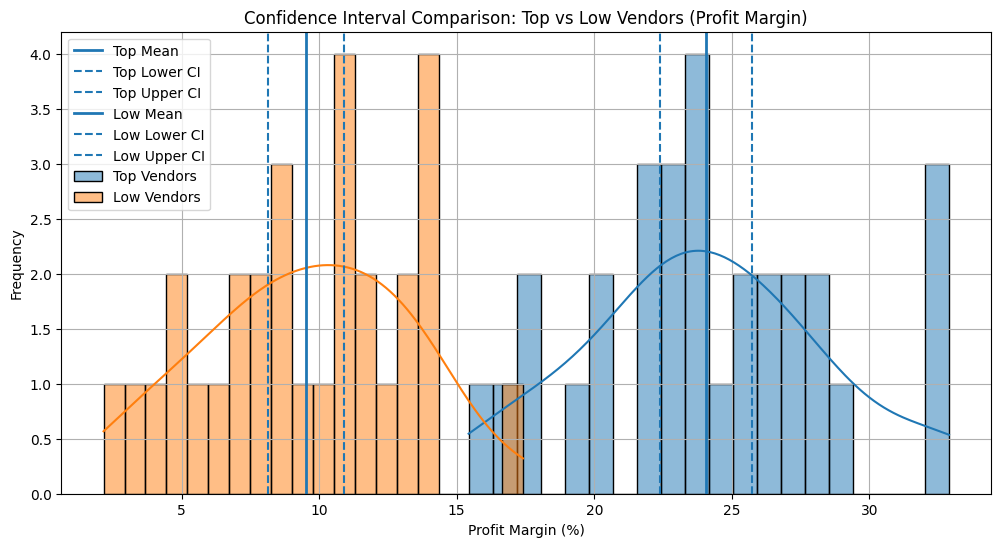

In [50]:

top_vendors_df = pd.DataFrame({
    "Vendor": [f"Vendor_{i}" for i in range(1, 31)],
    "ProfitMargin": np.random.normal(loc=25, scale=5, size=30)
})

low_vendors_df = pd.DataFrame({
    "Vendor": [f"Vendor_{i}" for i in range(31, 61)],
    "ProfitMargin": np.random.normal(loc=10, scale=4, size=30)
})


# STEP 1: EXTRACT NUMERIC DATA
top_vendors = top_vendors_df["ProfitMargin"].astype(float).values
low_vendors = low_vendors_df["ProfitMargin"].astype(float).values


# STEP 2: CONFIDENCE INTERVAL FUNCTION
def confidence_interval(data, confidence=0.95):
    data = np.array(data, dtype=float)
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")


# STEP 3: VISUALIZATION
plt.figure(figsize=(12, 6))

# Top Vendors
sns.histplot(top_vendors, bins=20, kde=True, alpha=0.5, label="Top Vendors")
plt.axvline(top_mean, linestyle="-", linewidth=2, label="Top Mean")
plt.axvline(top_lower, linestyle="--", label="Top Lower CI")
plt.axvline(top_upper, linestyle="--", label="Top Upper CI")

sns.histplot(low_vendors, bins=20, kde=True, alpha=0.5, label="Low Vendors")
plt.axvline(low_mean, linestyle="-", linewidth=2, label="Low Mean")
plt.axvline(low_lower, linestyle="--", label="Low Lower CI")
plt.axvline(low_upper, linestyle="--", label="Low Upper CI")

plt.title("Confidence Interval Comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()
